## Histograma de tiempo total de ejecución para 72 imágenes con diferentes estrategias de paralelización y en serie.

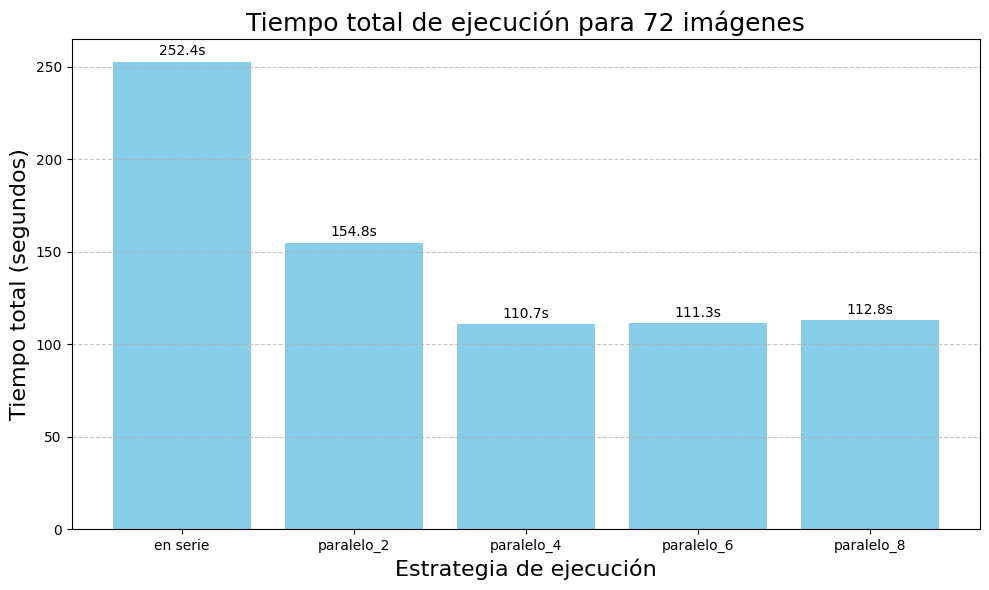

In [1]:
import matplotlib.pyplot as plt

# Datos
estrategias = ["en serie", "paralelo_2", "paralelo_4", "paralelo_6", "paralelo_8"]
tiempos = [252.39, 154.85, 110.67, 111.29, 112.85]

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(estrategias, tiempos, color='skyblue')

# Etiquetas y detalles
plt.title("Tiempo total de ejecución para 72 imágenes",fontsize=18)
plt.xlabel("Estrategia de ejecución",fontsize=16)
plt.ylabel("Tiempo total (segundos)",fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valores sobre cada barra
for i, tiempo in enumerate(tiempos):
    plt.text(i, tiempo + 2, f"{tiempo:.1f}s", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Tiempo promedio por imagen según el número de coeficientes de Zernike.

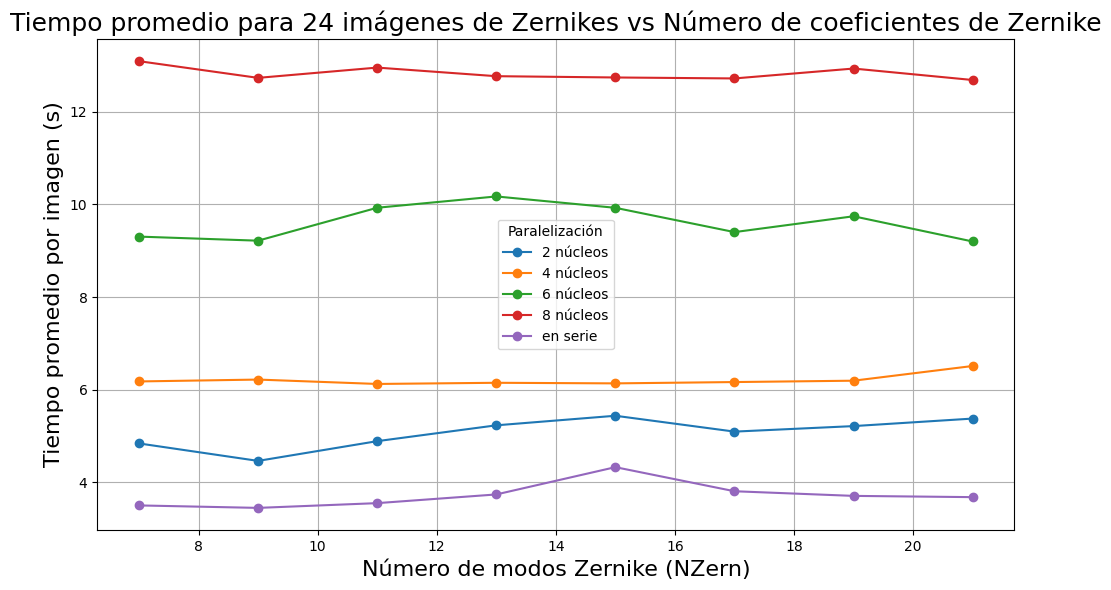

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Nombres de los archivos para cada número de núcleos
nucleos = [2, 4, 6, 8]
dataframes = {}

# Cargar los CSVs correspondientes a cada cantidad de núcleos
for n in nucleos:
    filename = f"results/zernike_parallel_timing_{n}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        dataframes[n] = df
df_serie = pd.read_csv("results/zernike_serial_timing.csv")
# Crear la gráfica
plt.figure(figsize=(10, 6))
for n, df in dataframes.items():
    plt.plot(df["NZern"], df["Avg_Time_s"], marker='o', label=f"{n} núcleos")
plt.plot(df_serie["NZern"], df_serie["Avg_Time_s"], marker='o', label=f"en serie")
plt.title("Tiempo promedio para 24 imágenes de Zernikes vs Número de coeficientes de Zernike",fontsize=18)
plt.xlabel("Número de modos Zernike (NZern)",fontsize=16)
plt.ylabel("Tiempo promedio por imagen (s)",fontsize=16)
plt.grid(True)
plt.legend(title="Paralelización")
plt.tight_layout()
plt.show()


## Tiempo total por 24 imágenes para diferentes cantidades de coeficientes de Zernike.

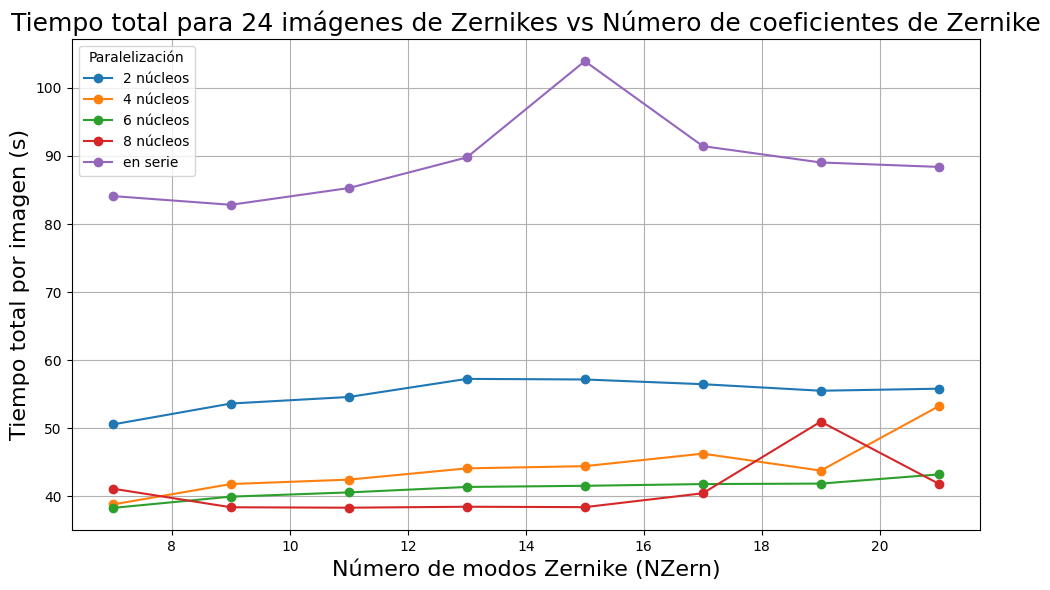

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Nombres de los archivos para cada número de núcleos
nucleos = [2, 4, 6, 8]
dataframes = {}

# Cargar los CSVs correspondientes a cada cantidad de núcleos
for n in nucleos:
    filename = f"results/zernike_parallel_timing_{n}_total.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        dataframes[n] = df
df_serie = pd.read_csv("results/zernike_serial_timing_total.csv")
# Crear la gráfica
plt.figure(figsize=(10, 6))
for n, df in dataframes.items():
    plt.plot(df["NZern"], df["Total_Time_s"], marker='o', label=f"{n} núcleos")
plt.plot(df_serie["NZern"], df_serie["Total_Time_s"], marker='o', label=f"en serie")
plt.title("Tiempo total para 24 imágenes de Zernikes vs Número de coeficientes de Zernike",fontsize=18)
plt.xlabel("Número de modos Zernike (NZern)",fontsize=16)
plt.ylabel("Tiempo total por imagen (s)",fontsize=16)
plt.grid(True)
plt.legend(title="Paralelización")
plt.tight_layout()
plt.show()

## Tiempo extrapolado de ejecución en función del tamaño del dataset.

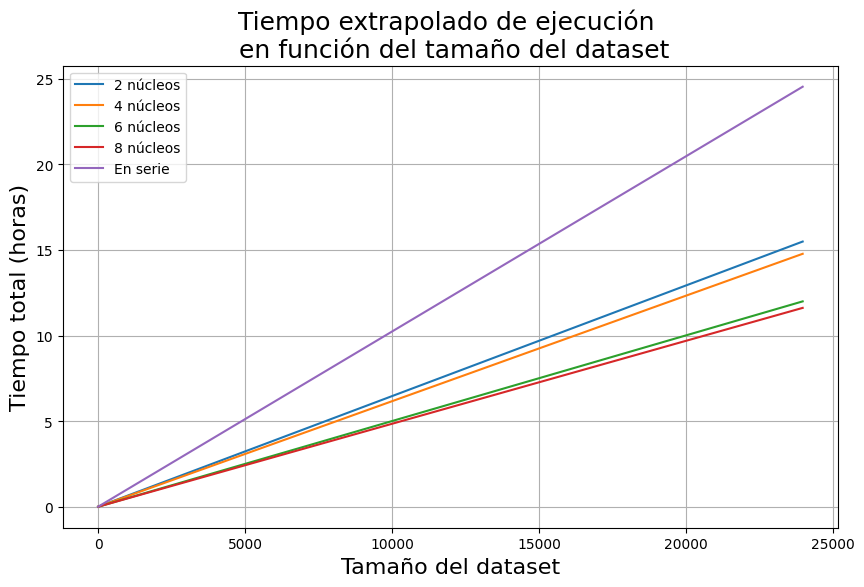

In [4]:
import numpy as np
plt.figure(figsize=(10, 6))
for i in [2,4,6,8]:
    plt.plot(np.arange(1000)*24,np.arange(1000)*dataframes[i].iloc[7].Total_Time_s/3600,label=f"{i} núcleos")
plt.plot(np.arange(1000)*24,np.arange(1000)*df_serie.iloc[7].Total_Time_s/3600,label=f"En serie")
plt.title("Tiempo extrapolado de ejecución \n en función del tamaño del dataset",fontsize=18)
plt.xlabel("Tamaño del dataset",fontsize=16)
plt.ylabel("Tiempo total (horas)",fontsize=16)
plt.legend()
plt.grid()
plt.show()